# SmeshLite — headless gym demo

Quick-iteration notebook: drives `SmeshLiteEnv` with `render_mode="none"` (no Pygame window),
so it runs at full CPU speed — useful for sanity-checking observations/rewards/action wiring
before kicking off a real training run.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from smeshlite import SmeshLiteEnv

env = SmeshLiteEnv(render_mode="none")
print("observation_space:", env.observation_space)
print("action_space:     ", env.action_space)

observation_space: Box(-2000.0, 2000.0, (22,), float32)
action_space:      MultiBinary(4)


## Reset and inspect a single observation

In [16]:
obs, info = env.reset(seed=0)
print("obs shape:", obs.shape, "dtype:", obs.dtype)
print("info:", info)
print("obs:", obs)

obs shape: (22,) dtype: float32
info: {'frame': 1}
obs: [-245.   70.    0.    0.    0.    3.    8.    1.    1.    1.    0.  245.
   70.    0.    0.    0.    3.    8.    1.   -1.    1.    0.]


## Random rollout

Drive P0 with random actions for a fixed number of steps, with P1 left idle
(the env's default `step()` behavior). Collect reward/damage/stocks for plotting.

In [17]:
N_STEPS = 600  # ~10s of in-game time at 60fps

obs, info = env.reset(seed=0)

rewards    = []
p0_damage  = []
p1_damage  = []

for _ in range(N_STEPS):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    rewards.append(reward)
    p0_damage.append(info["p0_damage"])
    p1_damage.append(info.get("p1_damage", 0.0))

    if terminated or truncated:
        print(f"episode ended at frame {info['frame']} — winner: {info['winner']}")
        obs, info = env.reset()

print("total reward:", sum(rewards))

total reward: 0.0


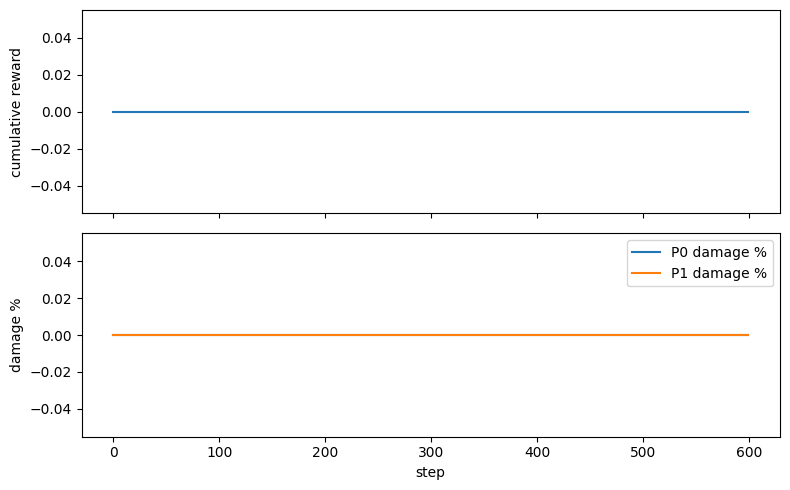

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(np.cumsum(rewards))
axes[0].set_ylabel("cumulative reward")

axes[1].plot(p0_damage, label="P0 damage %")
axes[1].plot(p1_damage, label="P1 damage %")
axes[1].set_ylabel("damage %")
axes[1].set_xlabel("step")
axes[1].legend()

fig.tight_layout()

## Self-play vs. a scripted bot

`step()` always drives P0 from `action` and leaves other players idle. To fight a
scripted opponent, set its brain directly on `env.match.characters[1]` *after* each
`reset()` — `reset()` rewires `ExternalBrain` onto every character, so the brain
needs to be re-applied each episode.

In [19]:
from agents.smesh_bot import SmeshBot

obs, info = env.reset(seed=0)
env.match.characters[1].set_brain(SmeshBot())

rewards = []
for _ in range(N_STEPS):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        print(f"episode ended at frame {info['frame']} — winner: {info['winner']}")
        obs, info = env.reset()
        env.match.characters[1].set_brain(SmeshBot())

print("total reward vs SmeshBot:", sum(rewards))

total reward vs SmeshBot: 1.8775


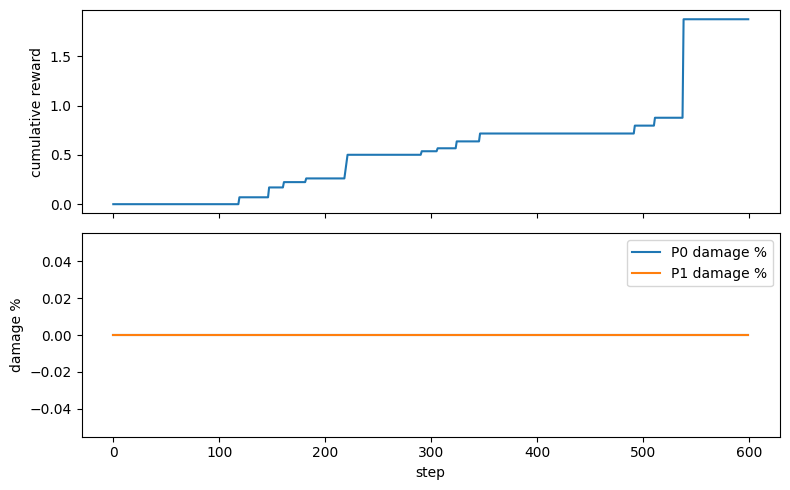

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(np.cumsum(rewards))
axes[0].set_ylabel("cumulative reward")

axes[1].plot(p0_damage, label="P0 damage %")
axes[1].plot(p1_damage, label="P1 damage %")
axes[1].set_ylabel("damage %")
axes[1].set_xlabel("step")
axes[1].legend()

fig.tight_layout()

## Gymnasium API check

In [20]:
from gymnasium.utils.env_checker import check_env

check_env(env.unwrapped)
print("check_env passed")

check_env passed


In [21]:
env.close()